In [1]:
%load_ext autoreload
%autoreload 2
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
paradigm = P300(resample=32, tmin=0, tmax=1, fmin=1, fmax=16)
dataset = BNCI2014008()

In [3]:
subject, session, run = 2, "session_0", "run_0"
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Not setting metadata
4200 matching events found
No baseline correction applied
0 bad epochs dropped


Number of events,4200
Events,NonTarget: 3500Target: 700
Time range,0.000 – 0.969 sec
Baseline,off


In [4]:
scaler = Scaler(scalings='mean', with_mean=False)
epochs._data = scaler.fit_transform(epochs._data)

In [5]:
X = epochs.get_data()
y = labels
print(X.shape)

(4200, 8, 32)


In [6]:
hoda = HODA(max_iter=64, rank=(8,32), tol=0, initialize ='random', verbose=True, toeplitz=1, taper=None,
            shrinkage='oas', solver='svd')
hoda.fit(X,y)

Iteration 0  updates: [ 5.37578997 19.40645256]  objective: 0.07296382493320289
Iteration 1  updates: [3.38784768 7.41070831]  objective: 0.07296382493320291
Iteration 2  updates: [8.12207732e-14 7.01301354e+00]  objective: 0.07296382493320289
Iteration 3  updates: [1.32116691e-13 6.82887057e+00]  objective: 0.07296382493320289
Iteration 4  updates: [1.79594599e-13 6.64821905e+00]  objective: 0.07296382493320289
Iteration 5  updates: [1.49538477e-13 6.71736841e+00]  objective: 0.07296382493320289
Iteration 6  updates: [1.79093000e-13 6.78579279e+00]  objective: 0.07296382493320289
Iteration 7  updates: [1.51101184e-13 7.00204790e+00]  objective: 0.07296382493320289
Iteration 8  updates: [1.39503281e-13 7.00429136e+00]  objective: 0.07296382493320289
Iteration 9  updates: [7.87278973e-14 6.67490232e+00]  objective: 0.07296382493320293
Iteration 10  updates: [1.11288412e-13 6.85688157e+00]  objective: 0.07296382493320291
Iteration 11  updates: [8.73116850e-14 6.92893229e+00]  objective: 

HODA(initialize='random', max_iter=64, rank=(8, 32), solver='svd', taper=None,
     tol=0, verbose=True)

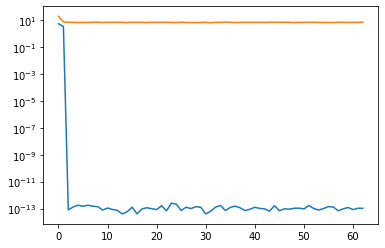

In [7]:
plt.semilogy(hoda.updates_[:,:hoda.iter_].T)
plt.show()

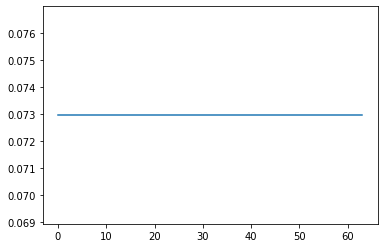

In [8]:
plt.plot(hoda.objective_)
plt.show()

(8, 32)


/tmp/ipykernel_61125/2637232329.py:16: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


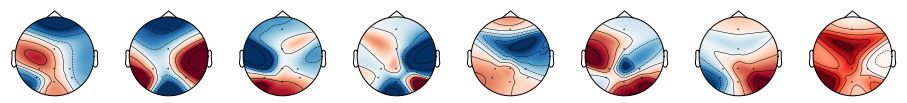

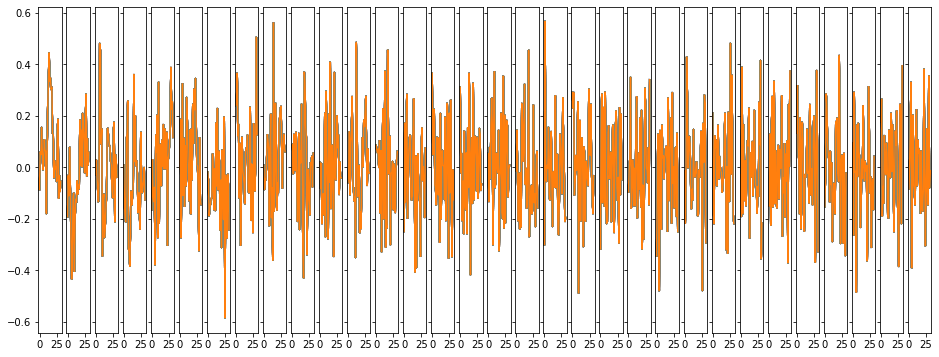

In [9]:
print(hoda.rank_)
for k in range(2):
    Uk = hoda.projs_[k]
    vmax = np.max(np.abs(Uk))
    fig, axs = plt.subplots(1,Uk.shape[1], figsize=(16,6), sharex=True, sharey=True)
    if Uk.shape[1]==1:
        axs = [axs]
    for i in range(Uk.shape[1]):
        if k==0:
            plot_topomap(Uk[:,i], epochs.info, axes=axs[i], show=False)        
        elif k == 1:
            for i in range(Uk.shape[1]):
                axs[i].plot(Uk[:,i])
        else:
            sns.heatmap(Uk, cmap='RdBu_r', vmin=-vmax, vmax=vmax, ax=axs[i])
    fig.show()

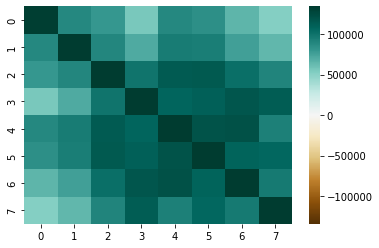

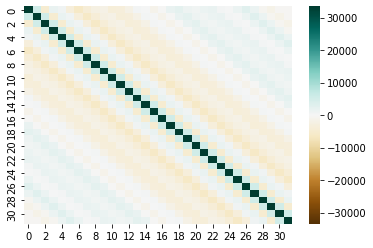

In [10]:
for k in range(2):
    sns.heatmap(hoda.scatter_w_[k], cmap='BrBG', vmin=-np.max(np.abs(hoda.scatter_w_[k])), vmax=np.max(np.abs(hoda.scatter_w_[k])))
    plt.show()

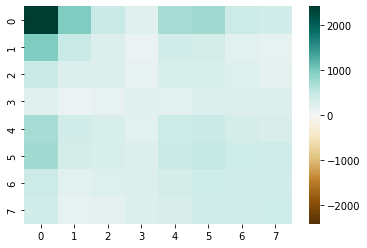

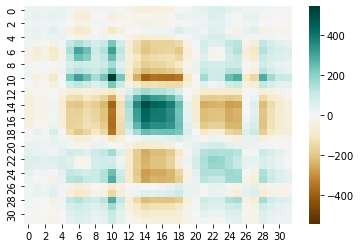

In [11]:
for k in range(2):
    sns.heatmap(hoda.scatter_b_[k], cmap='BrBG', vmin=-np.max(np.abs(hoda.scatter_b_[k])), vmax=np.max(np.abs(hoda.scatter_b_[k])))
    plt.show()

/tmp/ipykernel_61125/244461026.py:15: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


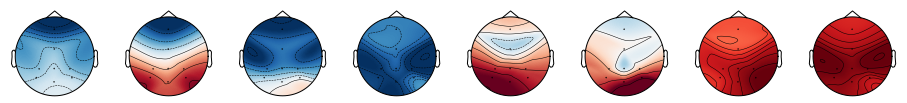

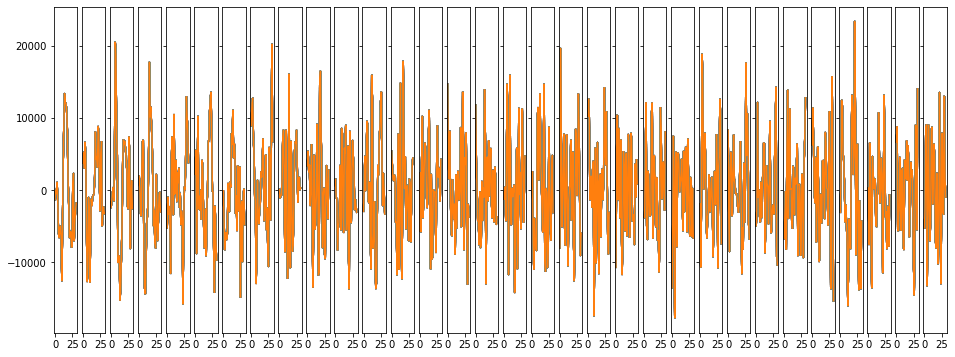

In [12]:
for k in range(2):
    patterns = (hoda.projs_[k].T@hoda.scatter_w_[k]).T
    vmax = np.max(np.abs(Uk))
    fig, axs = plt.subplots(1,patterns.shape[1], figsize=(16,6), sharex=True, sharey=True)
    if Uk.shape[1]==1:
        axs = [axs]
    for i in range(patterns.shape[1]):
        if k==0:
            plot_topomap(patterns[:,i], epochs.info, axes=axs[i], show=False)        
        elif k == 1:
            for i in range(patterns.shape[1]):
                axs[i].plot(patterns[:,i])
        else:
            sns.heatmap(patterns, cmap='RdBu_r', vmin=-vmax, vmax=vmax, ax=axs[i])
    fig.show()

In [13]:
Xt = hoda.transform(X)

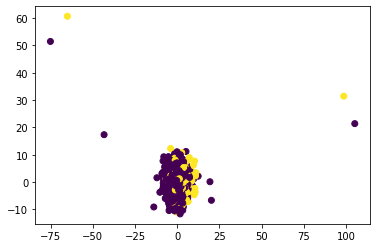

In [14]:
pca = PCA(n_components=2)
X_pc = pca.fit_transform(Xt)
plt.scatter(X_pc[:,0], X_pc[:,1],c=labels=='Target')

In [15]:
lda = LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
lda.fit(Xt,y)

LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')

In [16]:
roc_auc_score(y, lda.predict_proba(Xt)[:,1])

0.8601187755102041